<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by <a href="https://iitis.pl/pl/person/aglos" target="_blank"  >Adam Glos</a> and Özlem Salehi
        </td>        
</tr></table>

# Adders and numbers checking

To implement the oracle for solving Max-Cut problem, we first examine how to add numbers in a quantum way. 

## Half-adders

Suppose that we want to add two bits $A$ and $B$. $\Sigma$ represents the sum and $C_{out}$ represents the carry, that is an overflow to the next digit. Let's represent the relationship between the bits which are summed in the following table. 

<table>
    <tr>
        <td> $A$ </td>
        <td> $B$ </td>
        <td> $C_{\rm out}$</td>
        <td> $\Sigma$ </td>
    </tr>
    <tr>
        <td> 0 </td>
        <td> 0 </td>
        <td> 0 </td>
        <td> 0 </td>
    </tr>
    <tr>
        <td> 0 </td>
        <td> 1 </td>
        <td> 0 </td>
        <td> 1 </td>
    </tr>
    <tr>
        <td> 1 </td>
        <td> 0 </td>
        <td> 0 </td>
        <td> 1 </td>
    </tr>
    <tr>
        <td> 1 </td>
        <td> 1 </td>
        <td> 1 </td>
        <td> 0 </td>
    </tr>
</table>

Note that the third column is the AND operator on the first two, while the last is the XOR of first two. To implement this in a quantum circuit, we use four qubits as shown in the circuit below. We can use the following circuit to simulate the half-adder 

<img src="../images/half_adder.png" width="25%" align="center">

where the qubits 0 and 1 are the inputs and qubits 2 and 3 are the outputs.

Note that if qubit 3 represents $C_{out}$ and qubit 2 represents $\Sigma$, when we measure the state, we will observe $|C_{out}\rangle|\Sigma\rangle|B\rangle|A\rangle$. Hence, reading the first two bits gives us $C_{out}\Sigma$ which is the result of the summation. Order of $A$ and $B$ does not make any difference.

### Task 1 
Implement the above half-adder and verify that indeed it generates correct outputs for any input. 

In [ ]:
def half_addder(qc):
   # Your code here

In [ ]:
def initialize(qc, input):
    for i in range(len(input)):
        if input[i] == '1':
            qc.x(i)

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

for input in ['00','01','10','11']:
    qc = QuantumCircuit(4)
    initialize(qc, input)
    half_addder(qc)
    qc.measure_all()
    qc.draw('mpl')
    job = AerSimulator().run(qc, shots=1)
    counts = job.result().get_counts(qc)
    
    print("Input:", input)
    print("Added bits:", input[0] , "and", input[1])
    print("The sum should be equal to", int(input[0])+int(input[1]))
    cout = list(counts.keys())[0][0]
    sum_bit = list(counts.keys())[0][1]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Cout and Sum in binary:", cout + sum_bit)
    print("Cout and Sum in decimal:", 2*int(cout) + int(sum_bit))
    print("\n")

NameError: name 'half_addder' is not defined

[click for our solution](03_adders_and_numbers_checking_solutions.ipynb#task1)

Note that the half-adder above stores the solution on a separate qubit. We can think of this operation as `A + B`. 

Next, we will see that we can also implement in-place addition, `B+=A`. Fortunately, this can be done with the following circuit. 

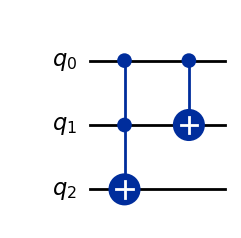

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)
qc.ccx(0, 1, 2)  
qc.cx(0, 1)     

qc.draw('mpl')

One can verify that if $\ket{q_0}$ and $\ket{q_1}$ are the digits being added, then on $\ket{q_1}$ we will have the sum bit $\Sigma$, and on $\ket{q_2}$ we will obtain the carry bit $C_{\rm out}$.

<table>
     <tr>
        <td colspan="3" align="center"> Input </td>
         <td> &nbsp; </td>
        <td colspan="3" align="center"> Output </td>
    </tr>
    <tr>
        <td> $q_0$ </td>
        <td> $q_1$ </td>
        <td> $q_2$</td>
        <td> &nbsp; </td>
        <td> $q_0$ </td>
        <td> $q_1$ </td>
        <td> $q_2$</td>
    </tr>
    <tr>
        <td> 0 </td>
        <td> 0 </td>
        <td> 0 </td>
        <td> &nbsp; </td>
        <td> 0 </td>
        <td> 0 </td>
        <td> 0 </td>
    </tr>
    <tr>
        <td> 0 </td>
        <td> 1 </td>
        <td> 0 </td>
        <td> &nbsp; </td>
        <td> 0 </td>
        <td> 1 </td>
        <td> 0 </td>
    </tr>
    <tr>
        <td> 1 </td>
        <td> 0 </td>
        <td> 0 </td>
        <td> &nbsp; </td>
        <td> 1 </td>
        <td> 1 </td>
        <td> 0 </td>
    </tr>
    <tr>
        <td> 1 </td>
        <td> 1 </td>
        <td> 0 </td>
        <td> &nbsp; </td>
        <td> 1 </td>
        <td> 0 </td>
        <td> 1 </td>
    </tr>
</table>


What happens if the qubit $\ket{q_2}$ is originally in state $\ket{1}$? Let's check the following table.

<table>
        <tr>
        <td colspan="3" align="center"> Input </td>
         <td> &nbsp; </td>
        <td colspan="3" align="center"> Output </td>
    </tr>
    <tr>
        <td> $q_0$ </td>
        <td> $q_1$ </td>
        <td> $q_2$</td>
        <td> &nbsp; </td>
        <td> $q_0$ </td>
        <td> $q_1$ </td>
        <td> $q_2$</td>
    </tr>
    <tr>
        <td> 0 </td>
        <td> 0 </td>
        <td> 1 </td>
        <td> &nbsp; </td>
        <td> 0 </td>
        <td> 0 </td>
        <td> 1 </td>
    </tr>
    <tr>
        <td> 0 </td>
        <td> 1 </td>
        <td> 1 </td>
        <td> &nbsp; </td>
        <td> 0 </td>
        <td> 1 </td>
        <td> 1 </td>
    </tr>
    <tr>
        <td> 1 </td>
        <td> 0 </td>
        <td> 1 </td>
        <td> &nbsp; </td>
        <td> 1 </td>
        <td> 1 </td>
        <td> 1 </td>
    </tr>
    <tr>
        <td> 1 </td>
        <td> 1 </td>
        <td> 1 </td>
        <td> &nbsp; </td>
        <td> 1 </td>
        <td> 0 </td>
        <td> 0 </td>
    </tr>
</table>

We see that, unless all $ q_0 $, $ q_1 $, and $ q_2 $ are in states $ \ket{1} $ at the same time,  we can use this circuit to add the single bit stored in qubit $ q_0 $ to the number stored on 2 qubits $q_1$ and $q_2$.

## Counting

Suppose that we are given $n$ bits and we are asked how many of the bits are set to 1. At this point, we know how to add two bits and now we will implement the procedure for counting by adding multiple bits consecutively on top of each other. 

We will store the output in qubits $\ket{q_2}$ and $\ket{q_3}$ where $\ket{q_2}$ represents the sum and $\ket{q_3}$ represents the carry. We will perform in place addition, meaning that we will first add the bit represented by $\ket{q_0}$ to the output and then do the same for the bit stored in $\ket{q_1}$.

In summary, we will perform the following operations: (`sum` is representing the sum stored in qubits $q_2$ and $q_3$.)

First, we do `sum = sum + q0` 

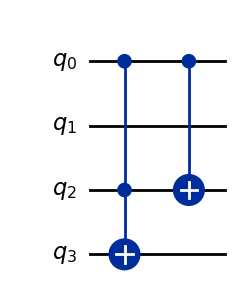

In [3]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(4)
circuit.ccx(0, 2, 3)
circuit.cx(0, 2)

circuit.draw('mpl') 

Note that initially $ q_2 $ is in state 0, and so we can also omit CCX.

After the first addition, $q_2$ either stores 0 or 1. Now let's add the bit stored in $q_1$ to the output.

Second, we do `sum = sum + q1`

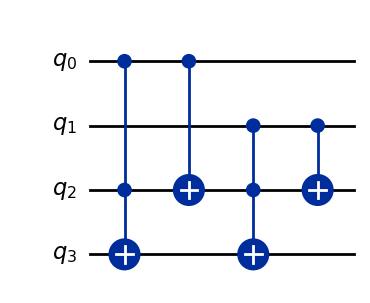

In [4]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)
qc.ccx(0, 2, 3)
qc.cx(0, 2)

qc.ccx(1, 2, 3)
qc.cx(1, 2)

qc.draw('mpl')

Now let's check the correctness of the above circuit by trying different inputs. Note that $q_3$ is the carry and $q_2$ is the sum. Therefore, when reading the output, we will observe $|C_{out}\rangle|\Sigma\rangle|q_1\rangle|q_0\rangle$

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def initialize(qc, input):
    for i in range(len(input)):
        if input[i] == '1':
            qc.x(i)

for input in ['00','01','10','11']:
    qc = QuantumCircuit(4)
    initialize(qc, input)

    # add qubit 0 
    # qubits 2. and 3. store the sum 
    # since we know that q[2] is set to zero initially, we could omit this control 
    qc.ccx(0, 2, 3)
    qc.cx(0, 2)

    ## add qubit 1
    qc.ccx(1, 2, 3)
    qc.cx(1, 2)
    qc.measure_all()

    result = AerSimulator().run(qc, shots=1).result()
    counts = result.get_counts()
    
    # print the sum and carry out (cout) values
    print("Input:", input)
    print("Added bits:", input[0] , "and", input[1])
    print("The sum should be equal to", int(input[0])+int(input[1]))
    cout = list(counts.keys())[0][0]
    sum_bit = list(counts.keys())[0][1]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Cout and Sum in binary:", cout + sum_bit)
    print("Cout and Sum in decimal:", 2*int(cout) + int(sum_bit))
    print("\n")

added bits: 0 and 0
Cout: 0
sum: 0
Cout and Sum in binary: 00 =  0


Input: 00
The sum should be equal to 0
According to quantum circuit: 
measurement output: {'0000': 1}
Cout and Sum in binary: 00
Cout and Sum in decimal: 0


added bits: 0 and 1
Cout: 0
sum: 1
Cout and Sum in binary: 01 =  1


Input: 01
The sum should be equal to 1
According to quantum circuit: 
measurement output: {'0110': 1}
Cout and Sum in binary: 01
Cout and Sum in decimal: 1


added bits: 1 and 0
Cout: 0
sum: 1
Cout and Sum in binary: 01 =  1


Input: 10
The sum should be equal to 1
According to quantum circuit: 
measurement output: {'0101': 1}
Cout and Sum in binary: 01
Cout and Sum in decimal: 1


added bits: 1 and 1
Cout: 1
sum: 0
Cout and Sum in binary: 10 =  2


Input: 11
The sum should be equal to 2
According to quantum circuit: 
measurement output: {'1011': 1}
Cout and Sum in binary: 10
Cout and Sum in decimal: 2




In the next task, you will implement the same procedure this time adding three bits stored in $q_0, q_1, q_2$. The sum will be stored in qubits $q_3$ and $q_4$. After adding the first two bits, it can be the case that $\ket{q_3}$ stores 0 and $\ket{q_4}$ stores 1, corresponding to the sum $2=10_2$.  From the table, we know that the same implementation idea still works independent of whether $\ket{q_4}$ stores 1 or not.

### Task 2 
Add the three bits stored in qubits 0-2 and store the sum on qubits 3-4.

In [ ]:
def initialize(qc, input):
    for i in range(len(input)):
        if input[i] == '1':
            qc.x(i)

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

for input in  ['000','001','010','011','100','101','110','111']:
    qc = QuantumCircuit(5)
    initialize(qc, input)

    # add qubit 0
 

    # add qubit 1


    # add qubit 2
  

    job = AerSimulator().run(qc, shots=1)
    counts = job.result().get_counts(qc)
   
    # print the sum
    print("Input:", input)
    print("Added bits:", input[0] , "and", input[1], "and", input[2])
    print("The sum should be equal to", int(input[0])+int(input[1])+int(input[2]))
    cout = list(counts.keys())[0][0]
    sum_bit = list(counts.keys())[0][1]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Cout and Sum in binary:", cout + sum_bit)
    print("Cout and Sum in decimal:", 2*int(cout) + int(sum_bit))
    print("\n")

QiskitError: 'No counts for experiment "<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10f030dd0>"'

[click for our solution](B03_Adders_And_Numbers_Checking_Solutions.ipynb#task2)

### Generalization  

Let's review the whole process from the beginning.

There are a single input bit $a_0$ and a single output bit, say $b_0$, initially set to $0$.  After the operation $b_0 = b_0+a_0 $, $ b_0 $ can be at most 1, which can be accomplished by using a single $CX$ operator.


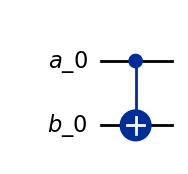

In [3]:
from qiskit import QuantumCircuit, QuantumRegister

#We name qubits to visualize the circuit in a more user friendly way
a_0 = QuantumRegister(1, name='a_0')
b_0 = QuantumRegister(1, name='b_0')
qc = QuantumCircuit(a_0, b_0)

qc.cx(a_0, b_0)          
qc.draw('mpl')

Now we add one more bit ($a_1$) to the summation. At this point, $b_0$ can be 0 or 1. If $a_1=1$ and $b_0=1$, then there will be an overflow to the next qubit since the sum will be $2=10_2$. We can check this using a $CCX$ gate where $a_1$ and $b_0$ are the control and $b_1$ is the target (qu)bits. (The same as the half adder above.)

Similarly, we can add $a_2$. If $a_2=1$ and the current sum is 1, then the new sum will be equal to 2 and the overflow will take place. If the current sum is equal to 2, then there is already an overflow and the new sum will become $3=11_2$.

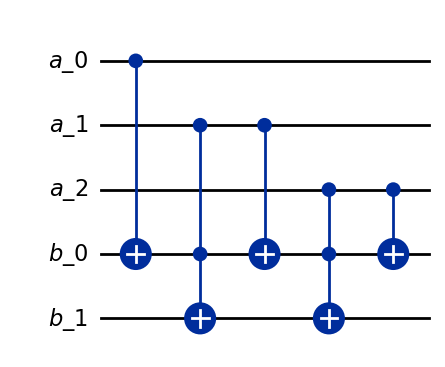

In [20]:
from qiskit import QuantumCircuit, QuantumRegister

a_0 = QuantumRegister(1, name='a_0')
a_1 = QuantumRegister(1, name='a_1')
a_2 = QuantumRegister(1, name='a_2')
b_0 = QuantumRegister(1, name='b_0')
b_1 = QuantumRegister(1, name='b_1')
qc = QuantumCircuit(a_0, a_1, a_2, b_0, b_1)

#Add a_0
qc.cx(a_0, b_0)

#Add a_1
qc.ccx(a_1, b_0, b_1)
qc.cx(a_1, b_0)

#Add a_2
qc.ccx(a_2, b_0, b_1)
qc.cx(a_2, b_0)

qc.draw('mpl')

Now we will add one more bit $a_3$. If $a_3= 1$ and both $b_0$ and $b_1$ are equal to 1, that is if the current sum is 3, then the sum will become 4 and we need an additional bit $b_2$. Hence, we need to check $a_3$, $b_0$, $b_1$ for equality to 1 and apply a $NOT$ gate to $\ket{b_2}$ if this is the case. 

Check the following circuit which implements summation of the first four bits. When we add the fourth bit, we introduce the multi-controlled $NOT$ as it is possible that the sum is equal to 3 at this point and an overflow takes place. We store the output in qubits $q_4$, $q_5$ and $q_6$, where $q_4$ is the least significant digit and $q_6$ is the most significant digit.

The line below generates all possible inputs of length 4 and we will use it in our code.

In [21]:
input_list = [bin(i)[2:].zfill(4) for i in range(0,2**4)]
print(input_list)

['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# Create quantum and classical registers

input_list = [bin(i)[2:].zfill(4) for i in range(0, 2**4)]

for input in input_list:
    # Reset circuit for each input
    a = QuantumRegister(4, name='a')   # input bits
    b = QuantumRegister(3, name='b')   # sum bits
    cl = ClassicalRegister(3, name='cl')  # we will only measure the output this time
    qc = QuantumCircuit(a, b, cl)

    # Initialize input bits
    for i in range(4):
        if input[i] == '1':
            qc.x(a[i])

    # Add a_0
    qc.cx(a[0], b[0])

    # Add a_1
    qc.ccx(a[1], b[0], b[1])
    qc.cx(a[1], b[0])

    # Add a_2
    qc.ccx(a[2], b[0], b[1])
    qc.cx(a[2], b[0])

    # Add a_3
    qc.mcx([a[2], b[0], b[1]], b[2])  # multi-controlled X for overflow
    qc.ccx(a[3], b[0], b[1])
    qc.cx(a[3], b[0])

    # Measurement
    qc.measure(b, cl)

    # Simulate
    result =  AerSimulator().run(qc, shots=1).result()
    counts = result.get_counts()

    # print the sum
    print("Input:", input)
    print("Added bits:", input[0] , "and", input[1], "and", input[2], "and", input[3])
    print("The sum should be equal to", int(input[0])+int(input[1])+int(input[2])+int(input[3]))
    first_digit = list(counts.keys())[0][0]
    second_digit = list(counts.keys())[0][1]
    third_digit = list(counts.keys())[0][2]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Result in binary:", first_digit + second_digit + third_digit, "= ", int(first_digit)*2**2 + int(second_digit)*2 + int(third_digit))
    print("\n")

Input: 0000
Added bits: 0 and 0 and 0 and 0
The sum should be equal to 0
According to quantum circuit: 
Measurement output: {'000': 1}
Cout and Sum in binary: 000
Result in binary: 000 =  0


Input: 0001
Added bits: 0 and 0 and 0 and 1
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Cout and Sum in binary: 001
Result in binary: 001 =  1


Input: 0010
Added bits: 0 and 0 and 1 and 0
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Cout and Sum in binary: 001
Result in binary: 001 =  1


Input: 0011
Added bits: 0 and 0 and 1 and 1
The sum should be equal to 2
According to quantum circuit: 
Measurement output: {'010': 1}
Cout and Sum in binary: 010
Result in binary: 010 =  2


Input: 0100
Added bits: 0 and 1 and 0 and 0
The sum should be equal to 1
According to quantum circuit: 
Measurement output: {'001': 1}
Cout and Sum in binary: 001
Result in binary: 001 =  1


Input: 0101
Added bits: 0 and 1 and 0 an

The same pattern will continue if we include the bits $ a_5, a_6, a_7 $. As the sum will be at most 7, we use still 3 bits for storing the output (summation).

After including $ a_8 $, we can have an overflow and so we use a multi-controlled not gate to check it. Besides, we use 4 bits for storing the output, which will be enough when adding $ a_9,\dots,a_{15} $.

This pattern repeats itself whenever including the new bits. A new qubit is used by the output when the $ 2^i $-th bit is included in the summation, and a new multi-controlled not gate should be used to check the overflow.

### Task 3

By using the above idea, add the values of seven bits, namely $ q_0,\ldots,q_6 $, and write the results on the qubits $ q_7,q_8, q_9 $, where $q_7$ is the least significant and $q_9$ is the most significant digit.

*Note:*  You may use for-loops instead of adding each qubit one by one.

In [25]:
# Generate the inputs
input_list = [bin(i)[2:].zfill(7) for i in range(0,2**7)]

In [ ]:
def initialize(qc, input):
    for i in range(len(input)):
        if input[i] == '1':
            qc.x(i)

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

n = 7 # Starting index of the sum qubits

for input in input_list:
    qc = QuantumCircuit(10, 3)

    #We can do the initialization inside a for loop
    initialize(qc, input)
    
    
    # add qubits

    
    qc.measure([n, n+1, n+2], range(3))

    # Simulate
    result =  AerSimulator().run(qc, shots=1).result()
    counts = result.get_counts()

    # print the sum
    print("Input:", input)
    print("The sum should be equal to", sum([int(bit) for bit in input]))
    first_digit = list(counts.keys())[0][0]
    second_digit = list(counts.keys())[0][1]
    third_digit = list(counts.keys())[0][2]
    print("According to quantum circuit: ")  
    print("Measurement output:", counts)
    print("Result in binary:", first_digit + second_digit + third_digit, "= ", int(first_digit)*2**2 + int(second_digit)*2 + int(third_digit))
    print("\n")

[click for our solution](B03_Adders_And_Numbers_Checking_Solutions.ipynb#task3)

## Checking the number

We have two qubits $ q_0 $ and $ q_1 $ storing an integer, and we are interested in checking whether this integer is equal to 3.

Let $ q_2 $ be the qubit for output in state $ \ket{0} $. We apply $X$ gate on $ q_2 $ if both $ q_0 $ and $q_1$ are in $ \ket{1} $. The following circuit implements this, where the binary value of the integer $ b $ has two digits $ b_1b_0 $ and $ b_i $ is represented by $ q_i $ for $ i \in \{0,1\} $.

Note that the binary number $b_1b_0$ is assumed to be represented in the circuit such that $q_0$ corresponds to $b_1$ and $b_0$ corresponds to $q_1$ in the rest of the discussion. 

The output is stored in qubit $q_2$, which will be the first bit of the measurement result.

In [28]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(3, 3)

# set qubits to store 3
qc.x(0)
qc.x(1)

# set qubits to store 2 (should not work!)
# qc.x(1)

# check wether both qubits are set to one
qc.ccx(0, 1, 2)
qc.measure([0, 1, 2], [0, 1, 2])

result = AerSimulator().run(qc, shots=1).result()
counts = result.get_counts()

print("Measurement output:", counts)

if list(counts.keys())[0][0] == '1':
    print("The number equals 3")
else:
    print("The number does not equal 3")

print(qc)

Measurement output: {'111': 1}
The number equals 3
     ┌───┐     ┌─┐      
q_0: ┤ X ├──■──┤M├──────
     ├───┤  │  └╥┘┌─┐   
q_1: ┤ X ├──■───╫─┤M├───
     └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ─────┤ X ├─╫──╫─┤M├
          └───┘ ║  ║ └╥┘
c: 3/═══════════╩══╩══╩═
                0  1  2 


Such a check is trivial when the binary representation of an integer contains only 1s, i.e., a multi-controled $NOT$ gate is applied on the output bit. Suppose that we have three qubits, and we are interested in checking whether their value is $ 110_2 = 6 $. In this case, the value of the output qubit is flipped if

- $q_0$ is in state $ \ket{1} $,
- $q_1$ is in state $ \ket{1} $, and
- $q_2$ is in state $ \ket{0} $.

To use a multi-controlled not gate, all control qubits should be in state $ \ket{1} $. Therefore, this time we do pre- and post- processing for $q_2$. We apply $X$ gate so that $q_2$ will be in state $ \ket{1} $ when applying the multi-controlled not gate if it is originally in $ \ket{0} $. After applying the multi-controlled not gate, we apply $X$ gate again to return the original value so that the change at this point will not affect the rest of computation.


### Task 4
Implement the algorithm that checks whether the first three qubits store the binary representation of number 6. Store the output on $q_3$.

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(4, 4)

# set qubits to 6 = 110_2:  q_2 q_1 q_0
qc.x(2)
qc.x(1)

# Your code here



qc.measure(list(range(4)), list(range(4)))

result = AerSimulator().run(qc, shots=1).result()
counts = result.get_counts()

print("Measurement output:", counts)

if list(counts.keys())[0][0] == '1':
    print("The number equals 6")
else:
    print("The number does not equal 6")

if not (list(counts.keys())[0][1] == '1' and list(counts.keys())[0][2] == '1' and list(counts.keys())[0][3] == '0'):
     print("The input qubits are not recovered")
else:
     print("The input qubits are recovered")
print(qc)

[click for our solution](03_adders_and_mumbers_checking_solutions.ipynb#task4)

## Inequality constraints 

What if there are two qubits $ q_1 $ and $ q_0 $ storing an integer ($q_0 + 2\cdot q_1$), and we are interested in checking whether this integer is greater than or equal to 2?

In this case, we are interested in checking wheter the value of the two qubits is $10_2=2$ or $11_2=3$. In both cases, the qubit $q_0$ is in state $\ket{1}$ and we are not interested in the state of the qubit $q_0$. Hence, the output qubit should be flipped if

- the qubit $q_1$ is in state $\ket{1}$.

We can check this using a $CX$-gate where $q_1$ is the control and $q_2$ is the target qubit.

The following program implements the above idea.

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

for input in ['00','01','10','11']:
    qc = QuantumCircuit(3, 1)

    # initialization, not the qubit orders q_1 q_0
    if input[0] == '1':
        qc.x(1)
    if input[1] == '1':
        qc.x(0)

    qc.cx(1, 2)
    qc.measure(2, 0)

    result = AerSimulator().run(qc, shots=1).result()
    counts = result.get_counts()
    print("Input:", input)
    print("Value of the input:", 2*int(input[0])+int(input[1]))
    
    if list(counts.keys())[0][0] == '1':
        print("The input is greater than or equal to 2")
    else:
        print("The input is not greater than or equal to 2")
    print("\n")

Input: 00
Value of the input: 0
The input is not greater than or equal to 2


Input: 01
Value of the input: 1
The input is not greater than or equal to 2


Input: 10
Value of the input: 2
The input is greater than or equal to 2


Input: 11
Value of the input: 3
The input is greater than or equal to 2




## Instance many-number checking 

We explained how to check the equality and inequality constraints. While classical computers are restricted to check one number at a time, quantum computers can do it instantly on a *superposition* of states. Hence, we can create a superposition of all possible integers represented by the input qubits using Hadamard gates, and then using the method above, we can check for equality or inequality constraints for the integers in superposition.

The circuit below has four qubits. The first three qubits hold an integer, and the last qubit is the output that returns the decision of whether the input is greater than or equal to 4 or not. Note that when you measure, you will observe only one of the numbers and whether it is at least 4.

Run the circuit several times to convince yourself the output is always correct.

In [35]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(4)

qc.h(range(3))

qc.cx(2, 3)

qc.measure_all()

result = AerSimulator().run(qc, shots=1).result()
counts = result.get_counts()

print("Measurement output:", counts)
number_measured = 2**2*int(list(counts.keys())[0][1]) + 2**1*int(list(counts.keys())[0][2]) + 2**0*int(list(counts.keys())[0][3])
print("Measured input:", number_measured)
if int(list(counts.keys())[0][0]) == 1:
    print("Input is greater than or equal to 4")
else:
    print("Input is not greater than or equal to 4")

Measurement output: {'1110': 1}
Measured input: 6
Input is greater than or equal to 4


### Task 5
Design a circuit that checks whether the first three qubits store either 4 or 5 in binary. 

*Hint:* Note that $4=100_2$ and $5=101_2$, hence $\ket{q_2}$ has to be set to $\ket{1}$, and $\ket{q_1}$ to $\ket{0}_2$, while $\ket{q_0}$ can be arbitrary.

*Hint:* Don't forget to recover the original state of the qubit by applying $X$ gate!

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(4, 4)

qc.h(list(range(3)))

# Your solution here

qc.measure(list(range(4)), list(range(4)))
result = AerSimulator().run(qc, shots=1).result()

counts = result.get_counts()
print("Measurement output:", counts)

number_measured = 2**2*int(list(counts.keys())[0][1]) + 2**1*int(list(counts.keys())[0][2]) + 2**0*int(list(counts.keys())[0][3])
print("Number measured:", number_measured)
if int(list(counts.keys())[0][0]) == 1:
    print("It is 4 or 5")
else:
    print("It is neither 4 nor 5")

[click for our solution](03_adders_and_numbers_checking_solutions.ipynb#task5)